<a href="https://colab.research.google.com/github/JosueRomeroQuesada/Desaf-o_AluraStoreLatam_Josu-RQ/blob/main/AluraStoreLatam_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [10]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [3]:

import pandas as pd



total_income_tienda1 = tienda['Precio'].sum()
total_income_tienda2 = tienda2['Precio'].sum()
total_income_tienda3 = tienda3['Precio'].sum()
total_income_tienda4 = tienda4['Precio'].sum()

print(f"Total income for tienda 1: {total_income_tienda1}")
print(f"Total income for tienda 2: {total_income_tienda2}")
print(f"Total income for tienda 3: {total_income_tienda3}")
print(f"Total income for tienda 4: {total_income_tienda4}")


Total income for tienda 1: 1150880400.0
Total income for tienda 2: 1116343500.0
Total income for tienda 3: 1098019600.0
Total income for tienda 4: 1038375700.0


# 2. Ventas por categoría

In [13]:
import pandas as pd

# Concatenate all DataFrames into a single DataFrame
all_stores = pd.concat([tienda, tienda2, tienda3, tienda4], keys=['tienda', 'tienda2', 'tienda3', 'tienda4'], names=['Tienda', 'Index'])

# Convert column names to lowercase for consistency
all_stores.columns = all_stores.columns.str.lower()

# Group by store and category, then count sales
sales_by_category = all_stores.groupby(['Tienda', 'categoría'])['precio'].count().reset_index(name='ventas')

# Sort by store and then by sales in descending order
sales_by_category = sales_by_category.sort_values(['Tienda', 'ventas'], ascending=[True, False])

sales_by_category

KeyError: 'categoría'

# 3. Calificación promedio de la tienda


In [12]:
# prompt: En este paso, debes calcular las calificaciones promedio de los clientes para cada tienda. El objetivo es conocer la satisfacción del cliente con los productos vendidos.

# Calculate the average rating for each store
average_ratings = all_stores.groupby('Tienda')['calificación'].mean()

average_ratings


,calificación
Tienda,
tienda,3.976685
tienda2,4.037304
tienda3,4.048326
tienda4,3.995759


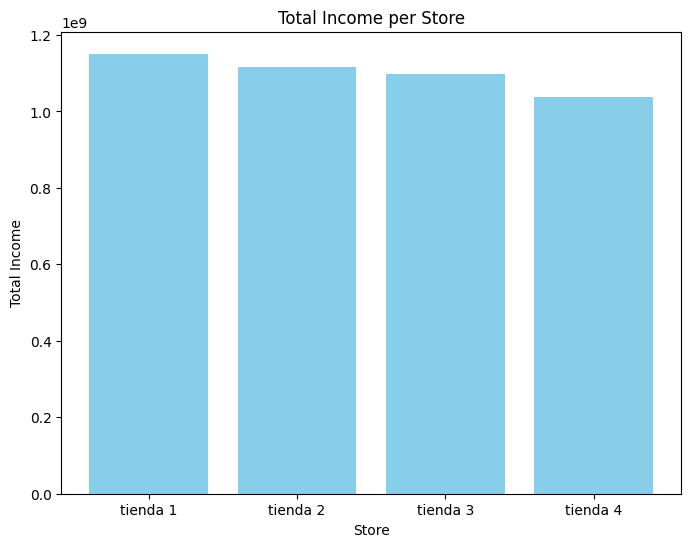

NameError: name 'sales_by_category' is not defined

<Figure size 1000x600 with 0 Axes>

In [22]:
# prompt: me puedes generar un grafico con esa informacion

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ... (your existing code to load data and calculate total income, sales by category, and average ratings)

# --- Visualization 1: Total Income per Store ---
stores = ['tienda 1', 'tienda 2', 'tienda 3', 'tienda 4']
incomes = [total_income_tienda1, total_income_tienda2, total_income_tienda3, total_income_tienda4]

plt.figure(figsize=(8, 6))
plt.bar(stores, incomes, color='skyblue')
plt.title('Total Income per Store')
plt.xlabel('Store')
plt.ylabel('Total Income')
plt.show()


# --- Visualization 2: Sales by Category (using seaborn) ---
plt.figure(figsize=(10, 6))
sns.barplot(x='categoría', y='ventas', hue='Tienda', data=sales_by_category)
plt.title('Sales per Category by Store')
plt.xlabel('Category')
plt.ylabel('Sales Count')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

# --- Visualization 3: Average Rating per Store ---
plt.figure(figsize=(6, 4))
plt.bar(average_ratings.index, average_ratings.values, color='lightgreen')
plt.title('Average Rating per Store')
plt.xlabel('Store')
plt.ylabel('Average Rating')
plt.show()


# 4. Productos más y menos vendidos

<ipython-input-14-9580de4e13a4>:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_products = df.groupby('Tienda').apply(lambda x: x.nlargest(n, 'ventas')).reset_index(drop=True)
<ipython-input-14-9580de4e13a4>:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bottom_products = df.groupby('Tienda').apply(lambda x: x.nsmallest(n, 'ventas')).reset_index(drop=True)


Top selling products:
    Tienda                   producto  ventas
0   tienda                    Armario      60
1  tienda2  Iniciando en programación      65
2  tienda3              Kit de bancas      57
3  tienda4                   Cama box      62

Bottom selling products:
    Tienda                   producto  ventas
0   tienda  Auriculares con micrófono      33
1  tienda2              Juego de mesa      32
2  tienda3    Bloques de construcción      35
3  tienda4         Guitarra eléctrica      33


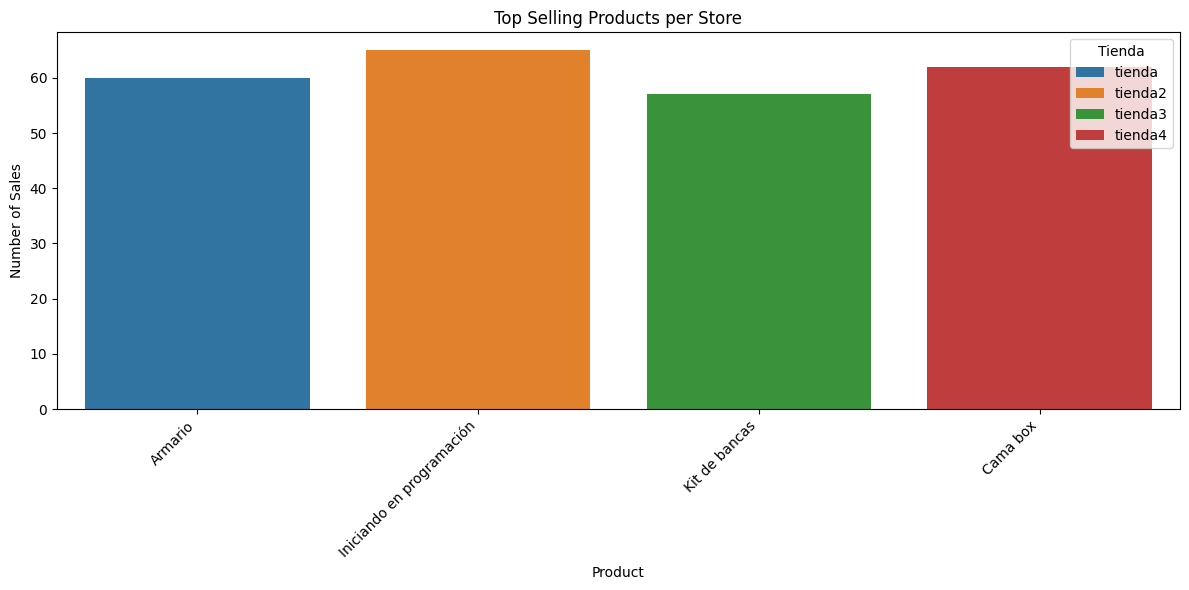

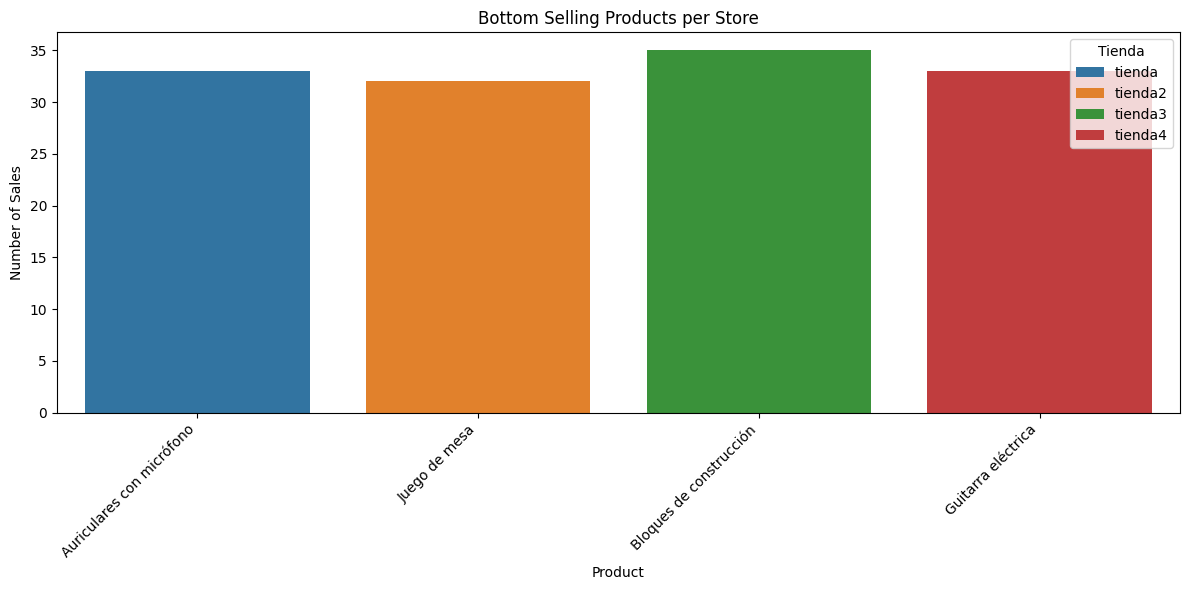

In [14]:
# prompt: En este paso, debes identificar qué productos fueron los más vendidos y los menos vendidos en cada tienda. Visualiza los resultados para que quede claro qué productos destacaron en ventas en cada tienda.

# Group by store and product, then count sales
sales_by_product = all_stores.groupby(['Tienda', 'producto'])['precio'].count().reset_index(name='ventas')

# Find the most and least sold products for each store
def top_bottom_products(df, n=1):  # n represents the number of top and bottom products you want to see
    top_products = df.groupby('Tienda').apply(lambda x: x.nlargest(n, 'ventas')).reset_index(drop=True)
    bottom_products = df.groupby('Tienda').apply(lambda x: x.nsmallest(n, 'ventas')).reset_index(drop=True)
    return top_products, bottom_products

top, bottom = top_bottom_products(sales_by_product)

print("Top selling products:")
print(top)

print("\nBottom selling products:")
print(bottom)

import matplotlib.pyplot as plt
import seaborn as sns

# Visualization of top selling products per store (bar plot)
plt.figure(figsize=(12, 6))
sns.barplot(x='producto', y='ventas', hue='Tienda', data=top)
plt.title('Top Selling Products per Store')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Product")
plt.ylabel("Number of Sales")
plt.tight_layout()
plt.show()

# Visualization of bottom selling products per store (bar plot)
plt.figure(figsize=(12, 6))
sns.barplot(x='producto', y='ventas', hue='Tienda', data=bottom)
plt.title('Bottom Selling Products per Store')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Product")
plt.ylabel("Number of Sales")
plt.tight_layout()
plt.show()


# 5. Envío promedio por tienda

In [20]:
# prompt: En este paso, debes calcular el costo de envío promedio para cada tienda. El objetivo es comprender cuánto se gasta, en promedio, en el envío de cada tienda.

# Calculate the average shipping cost for each store
# Changed 'Envío' to 'envío' to match the lowercase column names
average_shipping_cost = all_stores.groupby('Tienda')['envío'].mean()

average_shipping_cost


KeyError: 'Column not found: envío'